In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('default')

df = pd.read_csv('../data/online_retail_10_11.csv')
print("Shape:", df.shape)
print(df.head())
df.info()


Shape: (541910, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   ----- 

In [5]:
# Quick peek at column names
print(df.columns)

# If needed, adapt these names to your actual columns
# Common Online Retail columns: Invoice, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

# Drop rows without customer ID
df = df.dropna(subset=['CustomerID'])

# Parse dates (adjust column name if different, e.g. 'InvoiceDate')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Keep only positive quantities (remove returns)
df = df[df['Quantity'] > 0]

# Total amount per row (adjust 'UnitPrice' if your column is named 'Price' or similar)
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Snapshot date for recency calculation
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Snapshot date: {snapshot_date}")


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
Unique customers: 4339
Snapshot date: 2011-12-10 12:50:00


In [7]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    LastPurchaseDate=('InvoiceDate', 'max'),
    Country=('Country', lambda x: x.mode()[0])
).round(2)
# Remove extreme outliers to stabilize clustering
rfm = rfm[(rfm['Recency'] < 365) & (rfm['Frequency'] > 0)]

print(rfm.head())
print(rfm.describe())
print("Final customers used:", len(rfm))

rfm.to_csv('../data/rfm.csv')


            Recency  Frequency  Monetary    LastPurchaseDate         Country
CustomerID                                                                  
12346.0         326          1  77183.60 2011-01-18 10:01:00  United Kingdom
12347.0           2          7   4310.00 2011-12-07 15:52:00         Iceland
12348.0          75          4   1797.24 2011-09-25 13:13:00         Finland
12349.0          19          1   1757.55 2011-11-21 09:51:00           Italy
12350.0         310          1    334.40 2011-02-02 16:01:00          Norway
           Recency    Frequency       Monetary               LastPurchaseDate
count  4262.000000  4262.000000    4262.000000                           4262
mean     87.506335     4.322149    2084.636929  2011-09-13 12:21:47.752229120
min       1.000000     1.000000       0.000000            2010-12-10 13:48:00
25%      17.000000     1.000000     311.695000            2011-07-29 15:33:45
50%      50.000000     2.000000     689.305000            2011-10-21 10

In [8]:
print(df.columns.tolist())


['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']


In [9]:
# Use your actual columns
df = df.dropna(subset=['CustomerID'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[df['Quantity'] > 0]  # remove returns/negatives

# You already have TotalAmount, but recomputing is safe:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Snapshot date: {snapshot_date}")


Unique customers: 4339
Snapshot date: 2011-12-10 12:50:00


In [11]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    LastPurchaseDate=('InvoiceDate', 'max'),    # ← NEW
    Country=('Country', lambda x: x.mode()[0]) # ← NEW
).round(2)


# Remove extreme outliers to stabilize clustering
rfm = rfm[(rfm['Recency'] < 365) & (rfm['Frequency'] > 0)]

print(rfm.head())
print(rfm.describe())
print("Final customers used:", len(rfm))

rfm.to_csv('../data/rfm.csv')


            Recency  Frequency  Monetary    LastPurchaseDate         Country
CustomerID                                                                  
12346.0         326          1  77183.60 2011-01-18 10:01:00  United Kingdom
12347.0           2          7   4310.00 2011-12-07 15:52:00         Iceland
12348.0          75          4   1797.24 2011-09-25 13:13:00         Finland
12349.0          19          1   1757.55 2011-11-21 09:51:00           Italy
12350.0         310          1    334.40 2011-02-02 16:01:00          Norway
           Recency    Frequency       Monetary               LastPurchaseDate
count  4262.000000  4262.000000    4262.000000                           4262
mean     87.506335     4.322149    2084.636929  2011-09-13 12:21:47.752229120
min       1.000000     1.000000       0.000000            2010-12-10 13:48:00
25%      17.000000     1.000000     311.695000            2011-07-29 15:33:45
50%      50.000000     2.000000     689.305000            2011-10-21 10

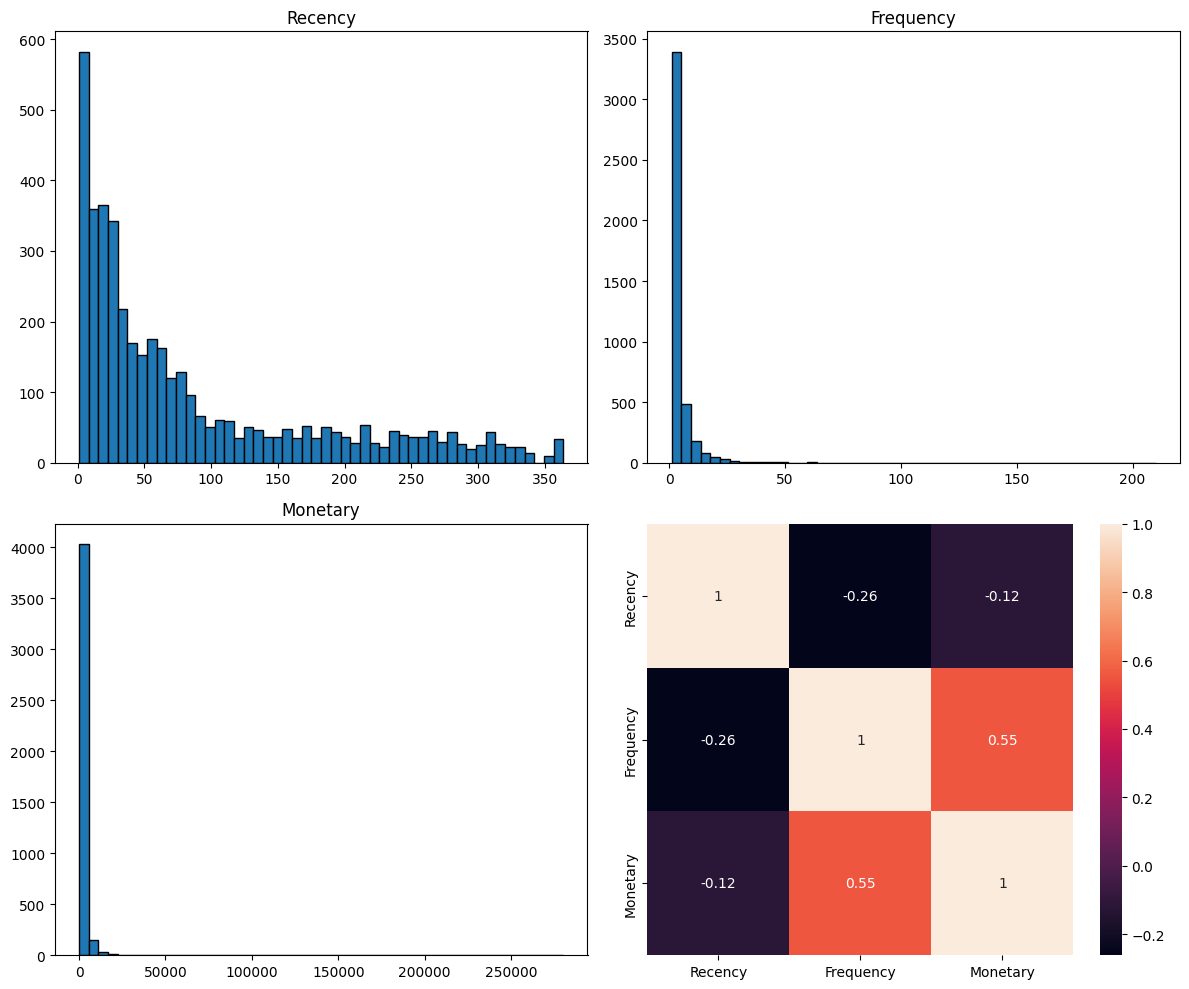

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    ax = axes[i // 2, i % 2]
    ax.hist(rfm[col], bins=50, edgecolor='black')
    ax.set_title(col)

sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True, ax=axes[1, 1])
plt.tight_layout()
plt.show()


In [14]:
# Save a cleaned transactions file for advanced features
df.to_csv('../data/transactions_clean.csv', index=False)
